In [1]:
!pip install insightface==0.7.3 # Or the latest stable version
!pip install onnxruntime
!pip install opencv-python numpy scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 10.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 102.6 MB/s eta 0:00:00
  Created wheel for insightface: filename=insightface-0.7.3-cp311-cp311-linux_x86_64.whl size=1060440 sha256=e454b17c9f201c99cf62cf68ddef60e00df59700988fd39dcde551667084d3cb
  Stored in directory: /root/.cache/pip/wheels/27/d8/22/f52d858d16cd06e7b2e6aad34a1777dcfaf000be833bbf8146
Successfully built insightface
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.3 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:121: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./insightface_models/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./insightface_models/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./insightface_models/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./insightface_models/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: ./insightface_models/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
CUDA not available, using C

Saving Face Recognition.zip to Face Recognition (1).zip
User uploaded file "Face Recognition (1).zip" with length 141374 bytes
'Face Recognition (1).zip' unzipped successfully into './enrolled_employee_images'.

--- Enrollment Phase (from unzipped images) ---
Employee 'Face Detection' already exists. Updating/adding face from ./enrolled_employee_images/Face Detection/Charlie Brown.jpg.
Successfully processed Face Detection from ./enrolled_employee_images/Face Detection/Charlie Brown.jpg.
Employee 'Face Detection' already exists. Updating/adding face from ./enrolled_employee_images/Face Detection/John Nelson.jpg.
Successfully processed Face Detection from ./enrolled_employee_images/Face Detection/John Nelson.jpg.
Employee 'Face Detection' already exists. Updating/adding face from ./enrolled_employee_images/Face Detection/Bob Johnson.jpg.
Successfully processed Face Detection from ./enrolled_employee_images/Face Detection/Bob Johnson.jpg.
Employee 'Face Detection' already exists. Updatin

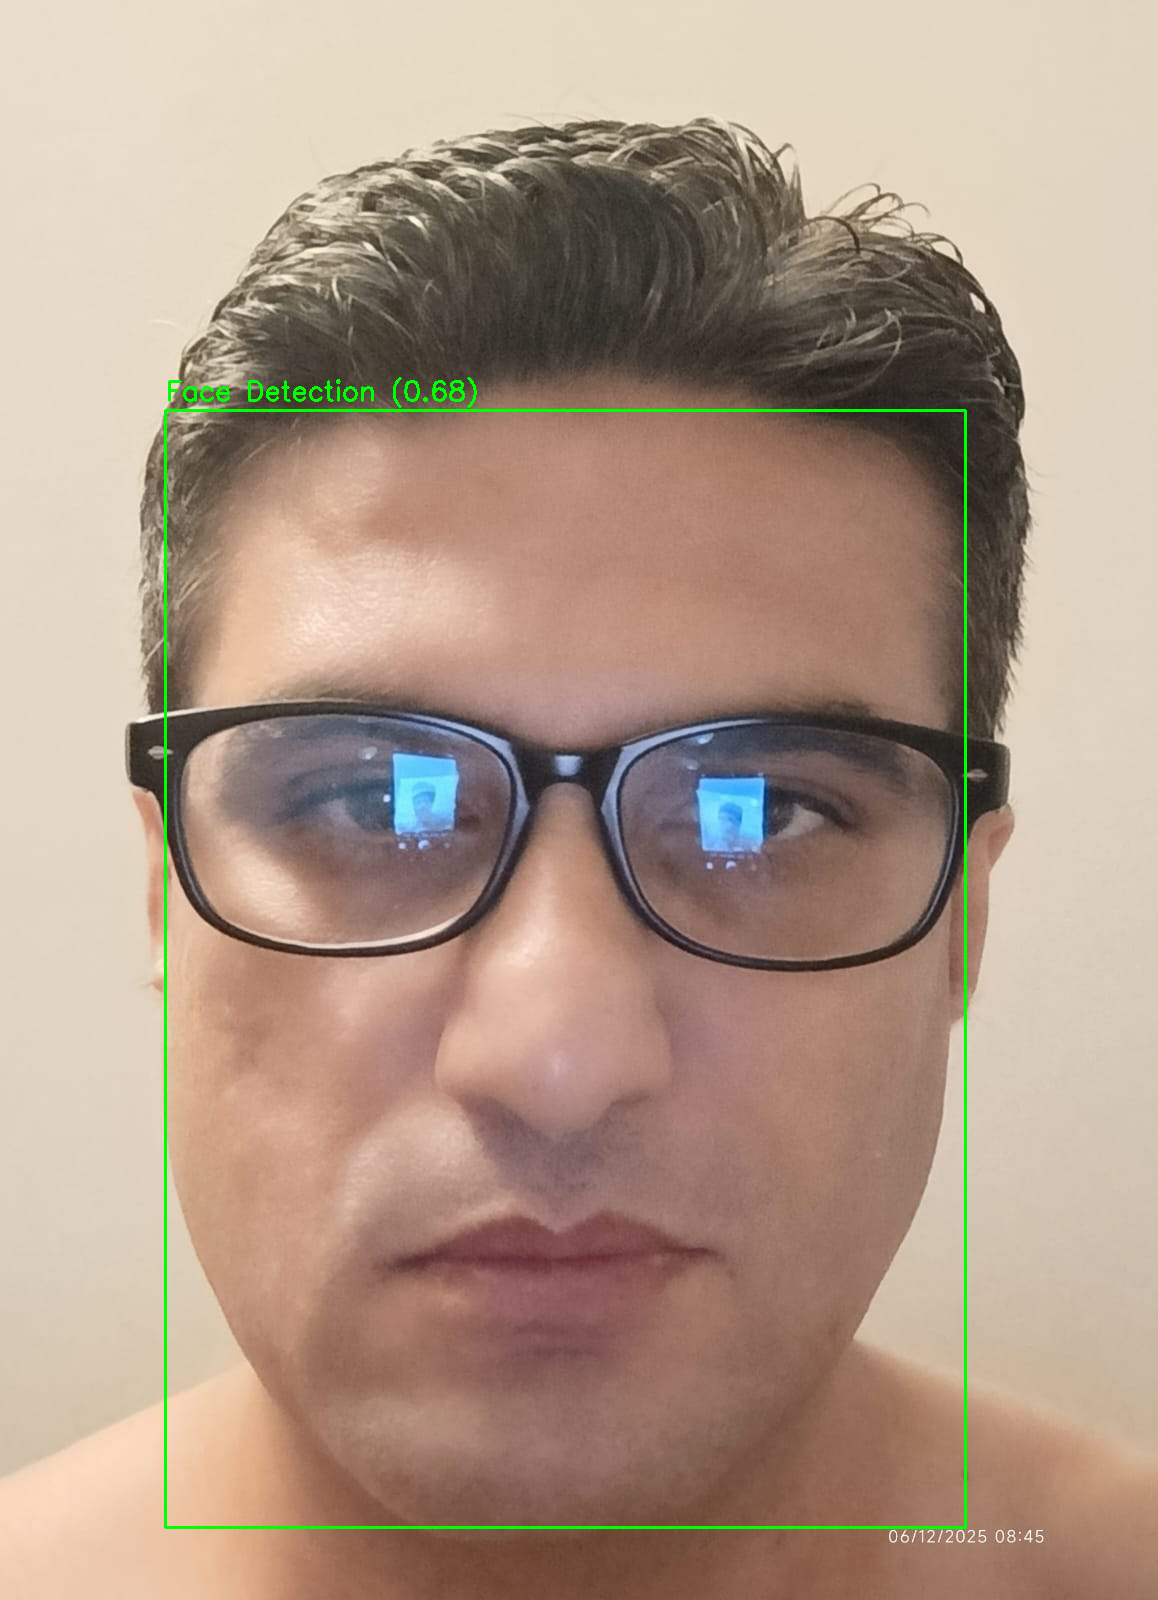

Image recognition complete.
Recognition session ended.


In [5]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
from sklearn.metrics.pairwise import cosine_similarity
import os
import time
from google.colab.patches import cv2_imshow # Import cv2_imshow
from google.colab import files # Import files for uploading
import zipfile # Import zipfile for unzipping

# --- Configuration ---
INSIGHTFACE_MODELS_ROOT = './insightface_models'
EMPLOYEE_EMBEDDINGS_FILE = 'employee_embeddings.npy'
EMPLOYEE_NAMES_FILE = 'employee_names.npy'

# Define the directory where extracted employee images will be placed
EMPLOYEE_IMAGES_DIR = './enrolled_employee_images' # New directory for unzipped images

SIMILARITY_THRESHOLD = 0.35

# --- Face Analysis Model Initialization ---
try:
    app = FaceAnalysis(name='buffalo_l', root=INSIGHTFACE_MODELS_ROOT)
    if cv2.cuda.getCudaEnabledDeviceCount() > 0:
        print("CUDA available, using GPU.")
        app.prepare(ctx_id=0, det_size=(640, 640))
    else:
        print("CUDA not available, using CPU.")
        app.prepare(ctx_id=-1, det_size=(640, 640))

    print("InsightFace model initialized successfully.")
except Exception as e:
    print(f"Error initializing InsightFace model: {e}")
    print("Please ensure 'insightface' and 'onnxruntime' are installed.")
    print("If using GPU, ensure CUDA is properly set up.")

# --- Employee Database (in-memory, loaded from files) ---
employee_embeddings = []
employee_names = []

def load_employee_database():
    """Loads employee embeddings and names from .npy files."""
    global employee_embeddings, employee_names
    if os.path.exists(EMPLOYEE_EMBEDDINGS_FILE) and os.path.exists(EMPLOYEE_NAMES_FILE):
        try:
            employee_embeddings = np.load(EMPLOYEE_EMBEDDINGS_FILE, allow_pickle=True).tolist()
            employee_names = np.load(EMPLOYEE_NAMES_FILE, allow_pickle=True).tolist()
            print(f"Loaded {len(employee_embeddings)} existing employees from files.")
        except Exception as e:
            print(f"Error loading employee database files: {e}. Starting with empty database.")
            employee_embeddings = []
            employee_names = []
    else:
        print("No existing employee database files found. Starting with an empty database.")

def save_employee_database():
    """Saves current employee embeddings and names to .npy files."""
    try:
        np.save(EMPLOYEE_EMBEDDINGS_FILE, np.array(employee_embeddings))
        np.save(EMPLOYEE_NAMES_FILE, np.array(employee_names))
        print("Employee database saved successfully.")
    except Exception as e:
        print(f"Error saving employee database: {e}")

# --- Enrollment Function ---
def enroll_employee(image_path, employee_name):
    """
    Enrolls a new employee by extracting their face embedding and storing it.
    Requires an image with a single, clear face.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image from {image_path}. Skipping.")
        return False

    faces = app.get(img)

    if len(faces) == 0:
        print(f"No face detected in {image_path} for {employee_name}. Skipping.")
        return False
    elif len(faces) > 1:
        print(f"Multiple faces detected in {image_path} for {employee_name}. Skipping.")
        return False
    else:
        # Check if employee name already exists
        if employee_name in employee_names:
            print(f"Employee '{employee_name}' already exists. Updating/adding face from {image_path}.")
            # You might want to implement a more robust update logic here,
            # e.g., only add if the new embedding is significantly different
            # or replace the existing one. For simplicity, we'll just add.

        embedding = faces[0].embedding
        employee_embeddings.append(embedding)
        employee_names.append(employee_name)
        # We'll save the database after all enrollments from the zip file
        print(f"Successfully processed {employee_name} from {image_path}.")
        return True

# --- Recognition Function ---
def recognize_person(frame):
    """
    Detects faces in a frame and attempts to recognize them against the employee database.
    Returns a list of dictionaries with face info (bbox, name, similarity, status).
    """
    if frame is None or frame.shape[0] == 0 or frame.shape[1] == 0:
        return []

    faces = app.get(frame)
    recognized_faces_info = []

    for face in faces:
        current_embedding = face.embedding

        if len(employee_embeddings) == 0:
            recognized_faces_info.append({
                "bbox": face.bbox.astype(int),
                "name": "Unknown Person",
                "similarity": 0.0,
                "status": "Unknown"
            })
            continue

        similarities = cosine_similarity(current_embedding.reshape(1, -1), np.array(employee_embeddings))
        max_similarity = np.max(similarities)
        best_match_idx = np.argmax(similarities)

        if max_similarity >= SIMILARITY_THRESHOLD:
            recognized_name = employee_names[best_match_idx]
            status = "Employee"
        else:
            recognized_name = "Unknown Person"
            status = "Unknown"

        recognized_faces_info.append({
            "bbox": face.bbox.astype(int),
            "name": recognized_name,
            "similarity": max_similarity,
            "status": status
        })

    return recognized_faces_info

# --- Main Application Logic ---
if __name__ == '__main__':
    load_employee_database() # Load existing employees at startup

    print("\n--- Upload and Unzip Employee Images ---")
    # Create the directory for unzipped images if it doesn't exist
    os.makedirs(EMPLOYEE_IMAGES_DIR, exist_ok=True)

    uploaded = files.upload() # This will open a file selection dialog

    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
        # Assuming the uploaded file is a zip file
        if fn.endswith('.zip'):
            with zipfile.ZipFile(fn, 'r') as zip_ref:
                # Extract all contents into the defined directory
                zip_ref.extractall(EMPLOYEE_IMAGES_DIR)
            print(f"'{fn}' unzipped successfully into '{EMPLOYEE_IMAGES_DIR}'.")
            # Clean up the zip file after extraction
            os.remove(fn)
        else:
            print(f"Warning: '{fn}' is not a zip file. Skipping unzipping.")
            # If it's a single image you want to enroll directly
            # you would handle it here, perhaps by moving it to EMPLOYEE_IMAGES_DIR
            # and calling enroll_employee on it. For now, we assume zip.

    # --- Enrollment Phase from Unzipped Folder ---
    print("\n--- Enrollment Phase (from unzipped images) ---")
    enrolled_count = 0
    # Walk through the extracted directory
    for root, dirs, files in os.walk(EMPLOYEE_IMAGES_DIR):
        # A common structure is: EMPLOYEE_IMAGES_DIR/EmployeeName/image.jpg
        # So, the employee name can be derived from the subfolder name
        employee_name = os.path.basename(root) # Get the last part of the path as employee name

        # Skip the root directory itself if it doesn't contain names directly
        if root == EMPLOYEE_IMAGES_DIR:
            continue

        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                image_path = os.path.join(root, file)
                # Call enroll_employee with the extracted path and derived name
                if enroll_employee(image_path, employee_name):
                    enrolled_count += 1

    # Save database only once after all images from the zip are processed
    if enrolled_count > 0:
        save_employee_database()
        print(f"Total {enrolled_count} faces processed and added/updated from uploaded zip.")
    else:
        print("No new faces were enrolled from the uploaded zip file.")


    print(f"Currently enrolled employees: {employee_names}")


    # --- Recognition Phase (from video or webcam / example image) ---
    print("\n--- Recognition Phase ---")
    # For demonstration in Colab, we stick to processing a single image
    # (replace with your desired image path or uncomment video/webcam parts if running locally)

    # Example images for recognition (make sure these paths exist after running the enrollment or upload)
    # You can upload new images directly to /content/ for testing recognition
    #RECOGNITION_IMAGE_PATH = '/content/Another_Athar.jpg' # <--- UPLOAD A TEST IMAGE HERE

    # Example: If your zip had 'Alice_Smith' and you want to test recognition for Alice
    # Make sure you upload a separate image for testing, not one that was already enrolled.
    RECOGNITION_IMAGE_PATH = '/content/Another_Athar.jpg'

    if os.path.exists(RECOGNITION_IMAGE_PATH):
        print(f"Processing recognition image: {RECOGNITION_IMAGE_PATH}")
        frame = cv2.imread(RECOGNITION_IMAGE_PATH)
        if frame is None:
            print(f"Error: Could not load recognition image from {RECOGNITION_IMAGE_PATH}")
        else:
            recognized_faces = recognize_person(frame)
            for face_info in recognized_faces:
                bbox = face_info["bbox"]
                name = face_info["name"]
                similarity = face_info["similarity"]
                status = face_info["status"]

                color = (0, 255, 0) if status == "Employee" else (0, 0, 255)

                cv2.rectangle(frame, (bbox[0], bbox[1]), (bbox[2], bbox[3]), color, 2)
                text = f"{name} ({similarity:.2f})"
                cv2.putText(frame, text, (bbox[0], bbox[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)

            cv2_imshow(frame)
            print("Image recognition complete.")
    else:
        print(f"Recognition image not found at {RECOGNITION_IMAGE_PATH}. Please upload a test image to /content/.")

    print("Recognition session ended.")